# Simulating data from a cognitive model

**Day 2, 14:00 — 30 minutes.** Alexander Fengler.

<img src="../../images/logos/ssm-simulators-logo.png" alt="ssm-simulators logo"
     style="display:block; margin:0.5rem auto 1.5rem auto; width:240px">

A cognitive model is, first and last, a **generative** story: parameters in,
data out. Before you fit anything, you should be able to push parameters
through the model and look at what comes back. That is what this session is
about.

We use [**ssm-simulators**](https://lnccbrown.github.io/ssm-simulators/), the
simulation layer of the HSSM ecosystem. It ships fast compiled simulators for
a large family of sequential-sampling models, and it is what generates the
training data behind the neural likelihoods you will meet tomorrow.

By the end you will have:

1. simulated from a model and understood the shape rules,
2. discovered the model zoo *by introspection* rather than by memorising names,
3. **built your own model** and simulated from it,
4. produced the dataset we dissect in the next session.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # -> tutorials/

import numpy as np
import matplotlib.pyplot as plt
import sbi4cogsci_style as S

S.use()
warnings.filterwarnings("ignore", category=UserWarning)

import ssms
from ssms import Simulator
from ssms.config import model_config

RANDOM_SEED = sum(map(ord, "sbi4cogsci-simulate"))
rng = np.random.default_rng(RANDOM_SEED)

print("ssm-simulators", ssms.__version__ if hasattr(ssms, "__version__") else "0.13.2")

ssm-simulators 0.13.2


## 1. One call, and the shape rules

The drift-diffusion model has four parameters: drift `v`, boundary height `a`,
relative start point `z`, and non-decision time `t`. Here the process runs
between $+a$ and $-a$, so `a` is the distance from zero to *one* bound — you
will also see "boundary separation" used for the full gap, which is $2a$.

The main entry point is the **`Simulator` class**. You build one for a model,
then call `.simulate()` as often as you like — the model configuration is
resolved once, at construction, rather than on every call.

In [2]:
sim = Simulator(model="ddm")

out = sim.simulate(theta=[0.5, 1.2, 0.5, 0.3],
                   n_samples=500,
                   random_state=RANDOM_SEED,
                   )

print("returned keys:", sorted(out.keys()))
print("rts    ", out["rts"].shape)
print("choices", out["choices"].shape, "->", np.unique(out["choices"]))

returned keys: ['choices', 'metadata', 'rts']
rts     (500, 1)
choices (500, 1) -> [-1  1]


Three things to notice, all of which cost people time:

1. **Choices are coded `-1` and `+1`**, not `0`/`1`. This convention runs
   through the whole ecosystem — HSSM will reject other codings for 2-choice
   models, and a *valid-but-wrong* `0`/`1` coding silently mismodels bias.
2. **The response key is `choices`**, and `rts` is 2-D — `(n_samples, 1)`,
   not a flat vector.

### The shape rule

There are three ways to ask for data, and mixing them up is the single most
common error. What you get back depends on **both** how many parameter sets
you hand in and how many samples you ask for:

| You want | `theta` | `n_samples` | shape of `rts` |
|---|---|---|---|
| many trials, **one** parameter set | vector `(n_params,)` | `n` | `(n, 1)` |
| **one** trial each, many parameter sets | matrix `(n_trials, n_params)` | `1` | `(n_trials, 1)` |
| many samples **per** parameter set | matrix `(n_trials, n_params)` | `n` | `(n, n_trials, 1)` |

The second form is how trial-varying parameters work — one row per trial —
and is what you need when drift depends on a condition, a covariate, or a
stimulus. The third is what you want for a parameter sweep, where you need a
whole distribution at each setting rather than a single draw.

In [3]:
# Third form: 7 parameter settings, 20 samples each.
theta_sweep = np.column_stack([
    np.linspace(-2.0, 2.0, 7),   # v varies
    np.full(7, 1.2),             # a
    np.full(7, 0.5),             # z
    np.full(7, 0.3),             # t
])
swept = sim.simulate(theta=theta_sweep, n_samples=20, random_state=RANDOM_SEED)
print("theta", theta_sweep.shape, "with n_samples=20 ->",
      "rts", swept["rts"].shape, "  (n_samples, n_trials, 1)")

theta (7, 4) with n_samples=20 -> rts (20, 7, 1)   (n_samples, n_trials, 1)


Now the trial-varying form, at a scale that also tells us something about
speed: 100,000 trials, drift ramping from strongly negative to strongly
positive.

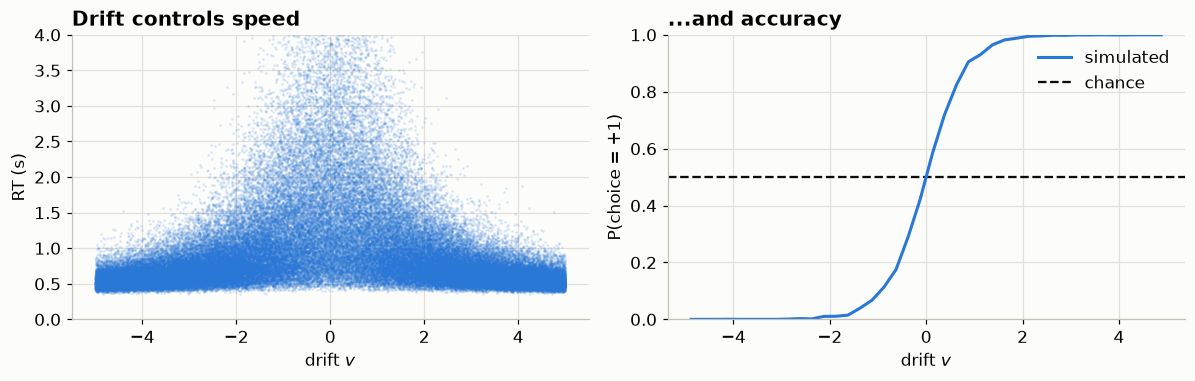

In [4]:
n_trials = 100_000
V_LO, V_HI = -5.0, 5.0
v_by_trial = np.linspace(V_LO, V_HI, n_trials)
theta_matrix = np.column_stack([
    v_by_trial,
    np.full(n_trials, 1.2),   # a
    np.full(n_trials, 0.5),   # z
    np.full(n_trials, 0.3),   # t
])

trialwise = sim.simulate(theta=theta_matrix, n_samples=1, random_state=RANDOM_SEED)
rt = trialwise["rts"].flatten()
ch = trialwise["choices"].flatten()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
ax1.plot(v_by_trial, rt, "o", color=S.PRIMARY, ms=1, alpha=0.10, ls="none")
ax1.set(title="Drift controls speed", xlabel="drift $v$", ylabel="RT (s)",
        ylim=(0, 4))

# Choice proportion in drift bins — binned across the FULL simulated range.
bins = np.linspace(V_LO, V_HI, 41)
idx = np.digitize(v_by_trial, bins) - 1
prop = [np.mean(ch[idx == i] == 1) if (idx == i).sum() else np.nan
        for i in range(len(bins) - 1)]
ax2.plot(0.5 * (bins[:-1] + bins[1:]), prop, "-", color=S.PRIMARY, lw=2,
         label="simulated")
S.truth_line(ax2, 0.5, label="chance")
ax2.set(title="...and accuracy", xlabel="drift $v$", ylabel="P(choice = +1)",
        ylim=(0, 1))
ax2.legend()
fig.tight_layout()

Accuracy **saturates**: past roughly $|v| = 3$ every trial goes the same way,
and pushing drift higher buys nothing observable. Hold on to that — it is the
mechanism behind the identifiability failure in the next session.

## 2. How fast is this, and does threading help?

You just simulated 100,000 trials. Worth knowing what that cost, because the
answer determines whether you ever need to think about performance again.

In [5]:
import time

t0 = time.time()
sim.simulate(theta=theta_matrix, n_samples=1, random_state=RANDOM_SEED)
elapsed = time.time() - t0
print(f"{n_trials:,} trials in {elapsed:.2f}s  "
      f"({n_trials / elapsed / 1000:.0f}k trials/second)")

100,000 trials in 0.82s  (121k trials/second)


The simulators are compiled Cython, so this is fast enough that simulation is
rarely your bottleneck — fitting is.

`simulate()` also takes an `n_threads` argument. Whether it does anything
depends on how your copy was **built**, and `ssm-simulators` ships a
diagnostic that tells you:

In [6]:
from cssm import _openmp_status

_openmp_status.print_status()

SSMS Parallel Execution Status
  OpenMP compiled:    No
  GSL compiled:       No
  Parallel ready:     No
  Max threads (OMP):  1
  Max threads limit:  256 (compile-time)
  CPU processors:     1
  OMP_NUM_THREADS:    (not set)
  Python cpu_count:   18

To enable full parallel support:
  OpenMP:
    macOS:  brew install libomp
    Linux:  apt install build-essential
  GSL:
    macOS:  brew install gsl
    Linux:  apt install libgsl-dev

  Then reinstall: pip install --force-reinstall ssm-simulators


## 3. The model zoo, by introspection

Do not memorise the model list — interrogate it. Every model carries its own
parameter names and the box those parameters live in.

In [7]:
import textwrap

names = sorted(model_config.keys())
print(f"{len(names)} models registered. The first 30, alphabetically:\n")
print(textwrap.fill(", ".join(names[:30]), width=76,
                    initial_indent="   ", subsequent_indent="   "))
print(f"\n   ... and {len(names) - 30} more.")

113 models registered. The first 30, alphabetically:

   addm, angle, conflict_ds, conflict_ds_angle, conflict_dsstimflex,
   conflict_dsstimflex_angle, conflict_stimflex, conflict_stimflex_angle,
   conflict_stimflexrel1, conflict_stimflexrel1_angle,
   conflict_stimflexrel1_leak, conflict_stimflexrel1_leak2, ddm, ddm_legacy,
   ddm_mic2_adj, ddm_mic2_adj_angle_no_bias,
   ddm_mic2_adj_conflict_gamma_no_bias, ddm_mic2_adj_no_bias,
   ddm_mic2_adj_weibull_no_bias, ddm_mic2_leak, ddm_mic2_leak_angle_no_bias,
   ddm_mic2_leak_angle_no_bias_no_lowdim_noise,
   ddm_mic2_leak_conflict_gamma_no_bias,
   ddm_mic2_leak_conflict_gamma_no_bias_no_lowdim_noise,
   ddm_mic2_leak_no_bias, ddm_mic2_leak_no_bias_no_lowdim_noise,
   ddm_mic2_leak_weibull_no_bias,
   ddm_mic2_leak_weibull_no_bias_no_lowdim_noise,
   ddm_mic2_multinoise_angle_no_bias,
   ddm_mic2_multinoise_conflict_gamma_no_bias

   ... and 83 more.


Each entry is a plain dictionary. Look at one in full — this is the whole
contract a model has to satisfy:

In [8]:
cfg = model_config["angle"]
for key, value in cfg.items():
    shown = value if not callable(value) else f"<callable {getattr(value, '__name__', '?')}>"
    print(f"  {key:<22} {str(shown)[:70]}")

  name                   angle
  params                 ['v', 'a', 'z', 't', 'theta']
  param_bounds           [[-3.0, 0.3, 0.1, 0.001, -0.1], [3.0, 3.0, 0.9, 2.0, 1.3]]
  boundary_name          angle
  boundary               <callable angle>
  n_params               5
  default_params         [0.0, 1.0, 0.5, 0.001, 0.0]
  nchoices               2
  choices                [-1, 1]
  n_particles            1
  simulator              <callable ddm_flexbound>
  parameter_transforms   {'sampling': [], 'simulation': []}
  param_bounds_dict      {'v': (-3.0, 3.0), 'a': (0.3, 3.0), 'z': (0.1, 0.9), 't': (0.001, 2.0)


The two fields you will reach for constantly are `params` (the names, **in
the order the simulator expects them**) and `param_bounds` (the box they are
valid in). Compare a few models:

In [9]:
for name in ["ddm", "angle", "weibull", "lba3"]:
    c = model_config[name]
    lo, hi = c["param_bounds"]
    box = ", ".join(f"{p} [{l:g}, {h:g}]" for p, l, h in zip(c["params"], lo, hi))
    print(f"{name:8s} choices={str(c['choices']):9s} {box}")

ddm      choices=[-1, 1]   v [-3, 3], a [0.3, 2.5], z [0.1, 0.9], t [0, 2]
angle    choices=[-1, 1]   v [-3, 3], a [0.3, 3], z [0.1, 0.9], t [0.001, 2], theta [-0.1, 1.3]
weibull  choices=[-1, 1]   v [-2.5, 2.5], a [0.3, 2.5], z [0.2, 0.8], t [0.001, 2], alpha [0.31, 4.99], beta [0.31, 6.99]
lba3     choices=[0, 1, 2] A [0, 1], b [0, 1], v0 [0, 1], v1 [0.1, 1.1], v2 [0.1, 0.5]


`angle` is the DDM plus one parameter, `theta`, which tilts the decision
boundary inward over time — the evidence needed to commit *decreases* the
longer you deliberate. Look at what that does, both to the boundary and to
the RT distribution.

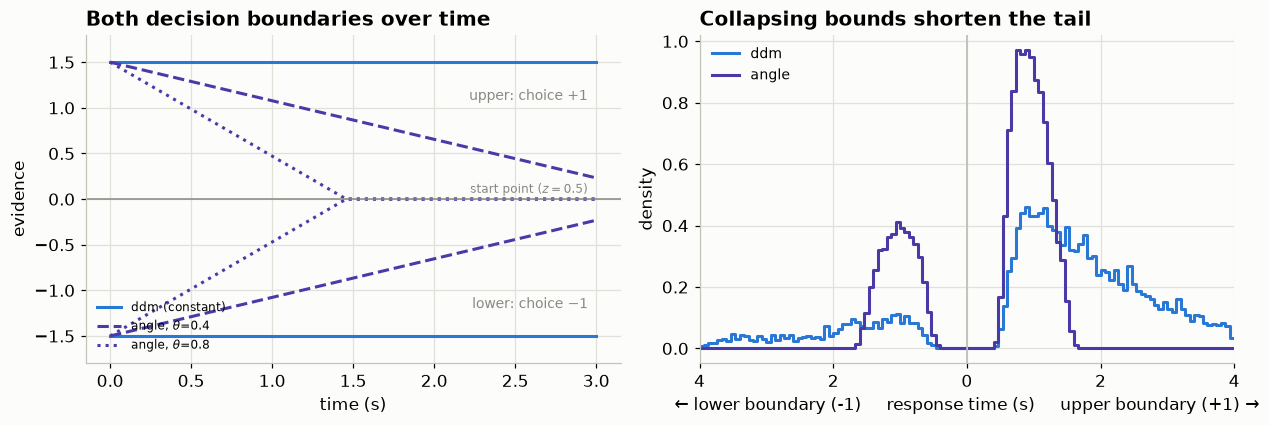

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.0))

# Left: the boundaries. Draw BOTH of them — a two-choice model has an upper and
# a lower bound, the start point sits between them, and evidence terminates at
# whichever it reaches first. Showing only the upper one hides half the model.
t_grid = np.linspace(0, 3, 200)
a0 = 1.5
ax1.plot(t_grid, np.full_like(t_grid, a0), color=S.PRIMARY, lw=2,
         label="ddm (constant)")
ax1.plot(t_grid, -np.full_like(t_grid, a0), color=S.PRIMARY, lw=2)
for theta_val, ls in [(0.4, "--"), (0.8, ":")]:
    bound = np.maximum(a0 - np.tan(theta_val) * t_grid, 0)
    ax1.plot(t_grid, bound, color=S.NAIVE, linestyle=ls, lw=2,
             label=f"angle, $\\theta$={theta_val}")
    ax1.plot(t_grid, -bound, color=S.NAIVE, linestyle=ls, lw=2)
ax1.axhline(0.0, color=S.MUTED, lw=1, ls="-")           # start point, z = 0.5
ax1.text(2.95, 0.06, "start point ($z = 0.5$)", fontsize=8, color=S.MUTED, ha="right")
ax1.text(2.95, a0 * 0.72, "upper: choice $+1$", fontsize=9, color=S.MUTED, ha="right")
ax1.text(2.95, -a0 * 0.72, "lower: choice $-1$", fontsize=9, color=S.MUTED,
         ha="right", va="top")
ax1.set(title="Both decision boundaries over time", xlabel="time (s)",
        ylabel="evidence", ylim=(-1.8, 1.8))
ax1.legend(loc="lower left", fontsize=8)

# Right: what that does to RTs, split by which boundary was reached.
for name, theta, colour in [("ddm", [0.5, 1.5, 0.5, 0.3], S.PRIMARY),
                            ("angle", [0.5, 1.5, 0.5, 0.3, 0.8], S.NAIVE)]:
    o = Simulator(model=name).simulate(theta=theta, n_samples=6000,
                                       random_state=RANDOM_SEED)
    S.signed_rt_hist(ax2, o["rts"], o["choices"], color=colour, label=name)
ax2.set(title="Collapsing bounds shorten the tail", ylabel="density")
S.label_choice_axis(ax2, rt_max=4.0)
ax2.legend(loc="upper left", fontsize=9)
fig.tight_layout()

That is the whole game: a parameter with a mechanistic meaning produces a
specific, *visible* signature in the data. Model building is choosing which
signatures you want to be able to express.

### Turn the knobs yourself

Two tools, both browser-based:

- **[ssms-gui](https://huggingface.co/spaces/franklab/ssms_gui)** — a dashboard
  for playing with `ssm-simulators` output directly, across the model zoo
  rather than just the DDM. Built for exactly this kind of build-intuition
  exploration.
- **[DDM explorer](https://stefanradev93.github.io/sbi4cogsci/tutorials/day2_bayes_toolkit/ddm-explorer.html)**
  — a companion page for this session: sliders over drift and boundary
  separation, showing what each does to the response-time distributions and
  to accuracy.

### Exercise 1

Pick any model from the zoo that we have not plotted, print its parameters
and bounds, simulate 2000 trials at a setting of your choice, and plot the RT
distribution split by choice.

<details>
<summary>One solution</summary>

```python
name = "weibull"
c = model_config[name]
print(c["params"], c["param_bounds"])

# v, a, z, t, alpha, beta  — alpha/beta shape the collapsing boundary
o = Simulator(model=name).simulate(
    theta=[0.6, 1.4, 0.5, 0.3, 2.0, 2.5], n_samples=2000, random_state=0)
rt, ch = o["rts"].flatten(), o["choices"].flatten()

fig, ax = plt.subplots(figsize=(6, 3.5))
for c_val, colour, lbl in [(1, S.PRIMARY, "+1"), (-1, S.NAIVE, "-1")]:
    ax.hist(rt[ch == c_val], bins=50, range=(0, 4), density=True,
            histtype="step", lw=2, color=colour, label=f"choice {lbl}")
ax.set(xlabel="RT (s)", ylabel="density", title=f"{name}: RT by choice")
ax.legend()
```

</details>

## 4. Capstone — build your own model

Two routes, depending on how far from a diffusion you want to go. Both are
about fifteen lines.

### Route A — keep the diffusion machinery, change the boundary

**Step 1 — write the function.** Nothing library-specific: it takes time `t`
plus its own parameters, and returns the boundary at that time.

The one rule that matters: it returns the **final boundary value**, `a`
included. `a` is an argument *to your function*, not a separate multiplier the
library applies afterwards — so `a` must be in its signature.

In [11]:
import numpy as np
from ssms.config import ModelConfigBuilder


def exp_collapse(t, a=1.0, rate=0.5):
    """Exponentially collapsing boundary: a * exp(-rate * t)."""
    return a * np.exp(-rate * np.asarray(t))


# It is an ordinary function; call and plot it before involving ssms at all.
print("at t=0:", exp_collapse(0.0, a=1.5, rate=0.6),
      " at t=1:", round(float(exp_collapse(1.0, a=1.5, rate=0.6)), 3))

at t=0: 1.5  at t=1: 0.823


**Step 2 — describe the model.** One call. A **model config** is the
dictionary that fully describes a model — `model_config["ddm"]` from section 3
was one. `from_model` copies an existing one and overrides the keys you name,
so you inherit everything about the DDM and change only what you mean to.

Four of the overrides swap in the boundary; three declare the new parameter.

In [12]:
cfg_custom = ModelConfigBuilder.from_model(
    "ddm",
    name="ddm_exp_collapse",
    # --- the boundary ---
    boundary=exp_collapse,            # the function itself
    boundary_name="exp_collapse",     # a label, for printing and metadata
    boundary_params=["a", "rate"],    # which parameters it receives
    # --- declare `rate` as a parameter of the model ---
    params=["v", "a", "z", "t", "rate"],
    n_params=5,
    param_bounds=[[-3.0, 0.3, 0.1, 0.0, 0.0],
                  [3.0, 2.5, 0.9, 2.0, 3.0]],
    default_params=[0.0, 1.0, 0.5, 0.001, 0.5],
)

print("params           :", cfg_custom["params"])
print("boundary_params  :", cfg_custom["boundary_params"])
print("param_bounds_dict:", cfg_custom["param_bounds_dict"])

params           : ['v', 'a', 'z', 't', 'rate']
boundary_params  : ['a', 'rate']
param_bounds_dict: {'v': (-3.0, 3.0), 'a': (0.3, 2.5), 'z': (0.1, 0.9), 't': (0.0, 2.0), 'rate': (0.0, 3.0)}


<details class="sbi-key" open>
<summary>🔑 <b>Why <code>a</code> is in both lists — it is applied once</b></summary>

The two lists answer different questions, which is why `a` appears in both:

- **`params`** — the parameters *you pass in* `theta`. This is the model's
  public interface: priors, bounds, and the sampling ranges used to train a
  neural likelihood all read this.
- **`boundary_params`** — a **routing declaration**. Which of those parameters
  get forwarded to your boundary function.

So `a` is listed twice but **used once**: it is a model parameter, and the
boundary function is what consumes it. The compiled simulator does not
multiply by `a` again — your function's return value *is* the boundary. Every
built-in agrees: `constant` takes `["a"]`, `angle` takes `["a", "theta"]`,
`weibull_cdf` takes `["a", "alpha", "beta"]`.

You can check this rather than take it on faith — the simulator hands back the
boundary it actually used, and we do exactly that two cells below.

</details>

**Step 3 — simulate from it.** From here it is an ordinary model.

rate = 0.15 (slow collapse)      P(upper) = 0.882
rate = 1.2 (fast collapse)       P(upper) = 0.777


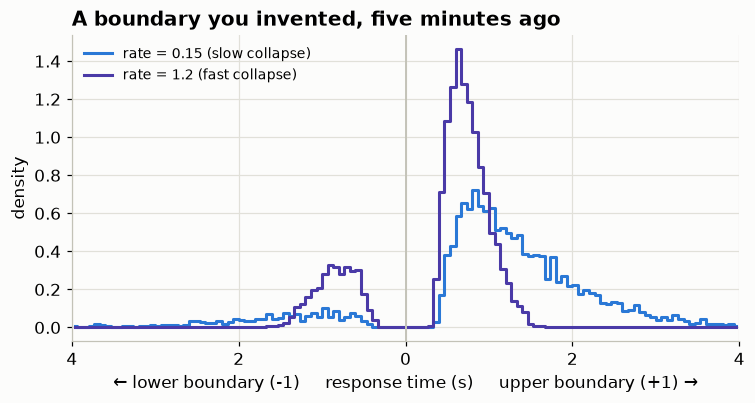

In [13]:
my_sim = Simulator(model=cfg_custom)
o_slow = my_sim.simulate(theta={"v": 0.8, "a": 1.5, "z": 0.5, "t": 0.2, "rate": 0.15},
                         n_samples=6000, random_state=RANDOM_SEED)
o_fast = my_sim.simulate(theta={"v": 0.8, "a": 1.5, "z": 0.5, "t": 0.2, "rate": 1.2},
                         n_samples=6000, random_state=RANDOM_SEED)

fig, ax = plt.subplots(figsize=(7.0, 3.8))
for o, colour, lbl in [(o_slow, S.PRIMARY, "rate = 0.15 (slow collapse)"),
                       (o_fast, S.NAIVE, "rate = 1.2 (fast collapse)")]:
    lower, upper = S.signed_rt_hist(ax, o["rts"], o["choices"],
                                    color=colour, label=lbl)
    print(f"{lbl:32s} P(upper) = {upper:.3f}")
ax.set(title="A boundary you invented, five minutes ago", ylabel="density")
S.label_choice_axis(ax, rt_max=4.0)
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()

A faster collapse means less evidence is required as time passes, so responses
arrive sooner — and because the bound drops symmetrically on both sides, the
accuracy advantage shrinks too. Both effects are visible at once in the
mirrored plot: the fast-collapse curve is pulled toward zero on *both* sides,
and its two sides are more nearly equal in area.

### Check the boundary rather than trusting it

`metadata["boundary"]` is the boundary the simulator actually evaluated, on
its internal time grid. Two things are worth reading off it, and the first
settles the "is `a` applied twice?" question directly.

In [14]:
b = o_slow["metadata"]["boundary"]
print(f"b(0)  = {b[0]:.4f}      <- equals a = 1.5 exactly, not 1.5^2 = 2.25")
print(f"b(t)  = {np.round(b[:4], 4)} ...")

# And it is the function we wrote, evaluated on that grid.
grid = np.arange(len(b)) * o_slow["metadata"]["delta_t"]
print("matches exp_collapse on the same grid:",
      np.allclose(b, exp_collapse(grid, a=1.5, rate=0.15), atol=1e-6))

b(0)  = 1.5000      <- equals a = 1.5 exactly, not 1.5^2 = 2.25
b(t)  = [1.5    1.4998 1.4996 1.4993] ...
matches exp_collapse on the same grid: True


That check is worth running whenever you attach a boundary, and not only to
settle an argument about `a` — because on some base models it would come back
telling you the boundary never took effect at all.

In [15]:
# Does this base model's engine actually honour a custom boundary? Sweep the
# collapse rate: if mean RT does not move, your function is being ignored.
for base in ["ddm", "angle", "ddm_legacy", "lba_angle_3"]:
    cfg = ModelConfigBuilder.from_model(base, boundary=exp_collapse,
                                        boundary_name="exp_collapse",
                                        boundary_params=["a", "rate"])
    theta = dict(zip(cfg["params"], cfg["default_params"]))
    theta["a"] = 1.5
    rts = []
    for rate in (0.01, 5.0):
        out = Simulator(cfg).simulate({**theta, "rate": rate}, n_samples=1500,
                                      random_state=RANDOM_SEED)
        rts.append(float(out["rts"][out["rts"] > 0].mean()))
    moved = abs(rts[0] - rts[1]) > 0.05
    print(f"  {base:14s} mean RT  {rts[0]:6.3f} -> {rts[1]:6.3f}   "
          f"{'boundary honoured' if moved else 'BOUNDARY IGNORED'}")

  ddm            mean RT   2.213 ->  0.254   boundary honoured
  angle          mean RT   2.213 ->  0.254   boundary honoured
  ddm_legacy     mean RT   0.574 ->  0.574   BOUNDARY IGNORED
  lba_angle_3    mean RT   2.871 ->  2.855   BOUNDARY IGNORED


<details class="sbi-warn" open>
<summary>⚠️ <b>Not every engine honours a custom boundary</b></summary>

`ddm`, `angle`, `weibull` and the rest of the `ddm_flexbound` family evaluate
your function on a time grid and walk against it. **`ddm_legacy`, `addm` and
the LBA models do not** — their compiled simulators compute the bound
internally and never call `boundary_fun`. You get no error and no warning,
just the base model's own behaviour.

`lba_angle_3` is the sharpest case: it declares `boundary_name="constant"`,
the config machinery dutifully routes `a` into `boundary_params`, and the
engine then drops it. The config advertises support the engine does not have.

So build custom boundaries on a flexbound-family base model, and run the sweep
above when you are unsure. Reported upstream — see the folder README.

</details>

<details class="sbi-warn" open>
<summary>⚠️ <b>Two ways a custom boundary goes wrong in silence</b></summary>

**Leave the new parameter out of `theta`** and it does not error — the
simulator falls back to the Python default in your function signature, with no
warning. `{"v":…, "a":…, "z":…, "t":…}` with no `rate` quietly simulates
`rate=0.5` because that is what `def exp_collapse(t, a=1.0, rate=0.5)` says.
Misspell it in `boundary_params` and you get the same silence.

**Leave it out of `params`** — i.e. skip the three declaration overrides above
— and dict-form `theta` still works perfectly, which is what makes this easy
to miss. It breaks only when you pass `theta` as an **array**:
`ValueError: model_param_list and theta array do not imply the same number of
parameters`. `validate_config` does **not** catch it either way. Anything that
reads the parameter box — priors, bounds, the ranges used to train a neural
likelihood — will not see `rate` until you declare it.
([ssm-simulators #308](https://github.com/lnccbrown/ssm-simulators/issues/308))

</details>

<details class="sbi-note">
<summary>📝 <b>The other route: registering a name</b></summary>

`register_boundary("exp_collapse", exp_collapse, ["a", "rate"])` adds your
function to a global registry, after which `from_model(..., boundary_name=…)`
or `ModelConfigBuilder.add_boundary(cfg, "exp_collapse")` can find it by
string. Useful when a boundary is shared across several configs.

We skipped it because it is a second concept that buys nothing here, and it
has a trap: **`add_boundary(cfg, "name", ["a", "rate"])` silently ignores that
third argument** when the boundary is a string — the parameter list comes from
the registry entry, so a list that disagrees with it is quietly discarded. The
third argument is only read when you pass a *callable*.

The registry is also in-memory and per-process: restart the kernel and the
name is gone. Passing the function object, as we did above, sidesteps all of
this — and it survives multiprocessing just as well, because either way the
function object ends up stored in the config that gets shipped to the worker.

</details>

### Route B — write the whole simulator

If your model is not a diffusion at all, hand over a function. It must accept
the parameters you declare plus `n_samples`, and return a dict with `rts`,
`choices` and `metadata`, where **`rts` and `choices` are 2-D**, shape
`(n_samples, 1)`.

P(choice = +1) = 0.663   (closed form v1/(v0+v1) = 0.667)


area on the +1 side = 0.663  (the closed form again)


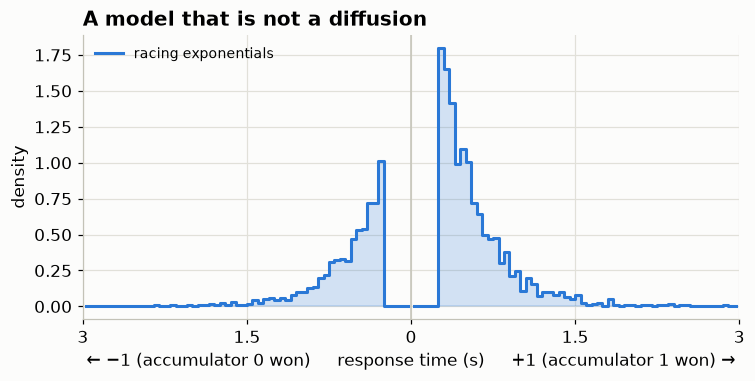

In [16]:
def racing_exponentials(v0, v1, t, n_samples=1000, max_t=20.0, delta_t=0.001,
                        random_state=None, **kwargs):
    """Two exponential accumulators race; the first to finish picks the choice.

    Not a diffusion at all — the interface is genuinely open.
    """
    import numpy as np
    rng = np.random.default_rng(random_state)
    finish_0 = rng.exponential(1.0 / v0, n_samples)
    finish_1 = rng.exponential(1.0 / v1, n_samples)
    rts = (np.minimum(finish_0, finish_1) + t).reshape(-1, 1)
    choices = np.where(finish_1 < finish_0, 1, -1).reshape(-1, 1)
    return {"rts": rts, "choices": choices,
            "metadata": {"model": "racing_exponentials", "n_samples": n_samples}}


race = Simulator(simulator_function=racing_exponentials,
                 params=["v0", "v1", "t"], nchoices=2)
o = race.simulate(theta={"v0": 1.0, "v1": 2.0, "t": 0.25},
                  n_samples=3000, random_state=RANDOM_SEED)

rt_r, ch_r = np.asarray(o["rts"]).flatten(), np.asarray(o["choices"]).flatten()
print(f"P(choice = +1) = {(ch_r == 1).mean():.3f}   "
      f"(closed form v1/(v0+v1) = {2/3:.3f})")

fig, ax = plt.subplots(figsize=(7.0, 3.6))
lower, upper = S.signed_rt_hist(ax, rt_r, ch_r, rt_max=3.0,
                                color=S.PRIMARY, label="racing exponentials",
                                fill=True)
ax.set(title="A model that is not a diffusion", ylabel="density")
S.label_choice_axis(ax, rt_max=3.0,
                    lower="$-1$ (accumulator 0 won)",
                    upper="$+1$ (accumulator 1 won)")
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()

print(f"area on the +1 side = {upper:.3f}  (the closed form again)")

The analytic check matters: for two racing exponentials,
$P(\text{choice}=+1) = v_1/(v_0+v_1)$. We recovered it. **If you find any close
close-form quantity that your simulator should reproduce, check it!** — it is the cheapest
bug detector.

### Exercise 2

Real response-time data almost always contains a few responses that the model
did not generate: button mashing, attention lapses, a sneeze. Extend
`racing_exponentials` with a **contaminant process**: with probability
$p_\text{lapse}$, a trial instead produces a uniform random RT in
$[0, 3]$ s and a coin-flip choice.

Simulate with $p_\text{lapse} = 0$ and $p_\text{lapse} = 0.1$ and plot both.
Where in the distribution does the contamination show up, and which part of
it would you expect to distort a fit the most?

<details>
<summary>Solution, and why this parameter matters</summary>

```python
def racing_with_lapse(v0, v1, t, p_lapse=0.0, n_samples=1000, max_t=20.0,
                      delta_t=0.001, random_state=None, **kwargs):
    import numpy as np
    rng = np.random.default_rng(random_state)
    f0 = rng.exponential(1.0 / v0, n_samples)
    f1 = rng.exponential(1.0 / v1, n_samples)
    rts = np.minimum(f0, f1) + t
    choices = np.where(f1 < f0, 1, -1)

    lapse = rng.random(n_samples) < p_lapse          # which trials are junk
    rts[lapse] = rng.uniform(0.0, 3.0, lapse.sum())
    choices[lapse] = rng.choice([-1, 1], lapse.sum())

    return {"rts": rts.reshape(-1, 1), "choices": choices.reshape(-1, 1),
            "metadata": {"model": "racing_with_lapse", "n_samples": n_samples}}

race_l = Simulator(simulator_function=racing_with_lapse,
                   params=["v0", "v1", "t", "p_lapse"], nchoices=2)

fig, ax = plt.subplots(figsize=(6.5, 3.6))
for p, colour in [(0.0, S.PRIMARY), (0.1, S.NAIVE)]:
    o = race_l.simulate(theta={"v0": 1.0, "v1": 2.0, "t": 0.25, "p_lapse": p},
                        n_samples=5000, random_state=0)
    ax.hist(np.asarray(o["rts"]).flatten(), bins=60, range=(0, 3), density=True,
            histtype="step", lw=2, color=colour, label=f"p_lapse = {p}")
ax.set(xlabel="RT (s)", ylabel="density"); ax.legend()
```

The contamination is nearly invisible in the bulk and obvious in the
**tails** — it puts mass at very short RTs that the race process essentially
never produces, and it fattens the slow tail. Those are exactly the regions a
likelihood cares most about: a single impossibly-fast response can have a
huge influence on the fit, because the model assigns it almost zero density.

This is not a toy concern. HSSM includes a lapse process **by default** —
`p_outlier=0.05` — for precisely this reason, and you will meet it tomorrow
morning. Now you know what it is protecting you from.

</details>

## 5. The dataset for the next session

We hand two datasets forward. Same model, same number of trials — the only
difference is the drift, and therefore the error rate.

In [17]:
import pandas as pd

def make_dataset(v, label, n=800, seed=RANDOM_SEED):
    o = sim.simulate(theta=[v, 1.2, 0.5, 0.3], n_samples=n, random_state=seed)
    return pd.DataFrame({"rt": o["rts"].flatten(),
                         "response": o["choices"].flatten().astype(int),
                         "design": label})

# v = 0.5 lands ~23% errors, inside the 15-35% band that Lüken et al. (2025)
# recommend for identifiability. v = 3.0 is the pathological case: ~0% errors.
balanced = make_dataset(0.5, "balanced")
extreme = make_dataset(3.0, "extreme")

for df in (balanced, extreme):
    err = (df["response"] == -1).mean()
    print(f"{df['design'][0]:9s} error rate {err:6.1%}   mean RT {df['rt'].mean():.3f}s")

outdir = pathlib.Path("data")
outdir.mkdir(exist_ok=True)
pd.concat([balanced, extreme]).to_csv(outdir / "ddm_two_designs.csv", index=False)
print(f"\nwrote {outdir / 'ddm_two_designs.csv'}")

balanced  error rate  22.9%   mean RT 1.579s
extreme   error rate   0.0%   mean RT 0.705s

wrote data/ddm_two_designs.csv


<details class="sbi-note">
<summary>📝 <b>Where this is going</b></summary>

Both datasets come from the *same model* with the *same* `a`, `z`, `t`. Only
the drift differs. One of them supports clean parameter recovery and the
other does not — and it is not the one most people would guess. That is the
next session.

</details>

**NOTE:**
`data/` is gitignored: it is regenerated by running this notebook, never
committed.

## 6. Where to go next

We stayed inside the two-choice diffusion family. The package goes
considerably further, and two directions are worth knowing about:

**Attentional drift-diffusion (`addm`)** — drift depends on where the
participant is *looking* on each moment of the trial, so fixation data enters
the model directly. Use it when you have eye-tracking alongside choices and
RTs.

```python
Simulator(model="addm")   # takes per-trial fixation data via extra_fields
```

**Reinforcement-learning SSMs (`ssms.rl`)** — the drift rate on each trial is
produced by a learning process, so choice, response time *and* learning are
modelled jointly. This is how you fit a bandit task where you care about both
what was learned and how the decision was made.

```python
import ssms.rl                # learning rules that feed an SSM
```

Both plug into HSSM the same way the models here do. If your project involves
eye-tracking or learning, start there rather than bolting it on later.


### Quick reference

| want to | call |
|---|---|
| build a simulator | `sim = Simulator(model="ddm")` |
| simulate | `sim.simulate(theta=[...], n_samples=n)` |
| list models | `model_config.keys()` |
| inspect one | `model_config["angle"]` |
| custom boundary | `from_model("ddm", boundary=fn, boundary_params=["a", ...], params=[...])` |
| check it took | `out["metadata"]["boundary"]` |
| bring your own simulator | `Simulator(simulator_function=fn, params=[...], nchoices=2)` |

**Next:** we take the two datasets we just wrote and find out what happens
when you try to recover the parameters that made them.